In [1]:
!pip install networkx matplotlib

Choosing a Model
The model names give you a hint about their capabilities and intended use:

Pro: These are the most capable models, ideal for complex reasoning, creative tasks, and detailed analysis.

Flash: These models are optimized for high speed and efficiency, making them great for summarization, chat applications, and tasks requiring rapid responses.

Gemma: These are lightweight, open-weight models suitable for a variety of text generation tasks and are great for experimentation.

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations

In [3]:
def create_process(edges):
    G = nx.DiGraph()
    for u, v in edges:
        G.add_edge(u, v)
    return G

In [4]:
edges1 = [
    ("Start","Receive"),
    ("Receive","Verify"),
    ("Verify","Check"),
    ("Check","Approve"),
    ("Approve","Create"),
    ("Create","End"),
]

G1 = create_process(edges1)

In [5]:
edges2 = [
    ("Start","Receive"),
    ("Receive","Verify"),
    ("Verify","Check"),
    ("Check","Approve"),
    ("Approve","Disburse"),
    ("Disburse","End"),
]

G2 = create_process(edges2)

In [6]:
edges3 = [
    ("Start","Receive"),
    ("Receive","Verify"),
    ("Verify","Check"),
    ("Check","Approve"),
    ("Approve","IssueCard"),
    ("IssueCard","End"),
]

G3 = create_process(edges3)

In [7]:
graphs = [G1, G2, G3]

In [8]:
def contains_subgraph(G, sub_edges):
    for u, v in sub_edges:
        if not G.has_edge(u, v):
            return False
    return True

In [9]:
def generate_subgraphs(G, size):

    edges = list(G.edges())

    subs = []

    for comb in combinations(edges, size):
        subs.append(list(comb))

    return subs

In [10]:
def support(sub_edges, graphs):

    count = 0

    for G in graphs:
        if contains_subgraph(G, sub_edges):
            count += 1

    return count

In [11]:
minsup = 3

frequent = []

subs = generate_subgraphs(G1, 3)

for s in subs:

    sup = support(s, graphs)

    if sup >= minsup:
        frequent.append((s, sup))

frequent

[([('Start', 'Receive'), ('Receive', 'Verify'), ('Verify', 'Check')], 3),
 ([('Start', 'Receive'), ('Receive', 'Verify'), ('Check', 'Approve')], 3),
 ([('Start', 'Receive'), ('Verify', 'Check'), ('Check', 'Approve')], 3),
 ([('Receive', 'Verify'), ('Verify', 'Check'), ('Check', 'Approve')], 3)]

In [12]:
subs = generate_subgraphs(G1, 4)
frequent = []
for s in subs:
    sup = support(s, graphs)
    if sup >= 3:
        frequent.append((s, sup))

frequent

[([('Start', 'Receive'),
   ('Receive', 'Verify'),
   ('Verify', 'Check'),
   ('Check', 'Approve')],
  3)]

In [13]:
def draw_subgraph(edges):

    G = nx.DiGraph()

    for u, v in edges:
        G.add_edge(u, v)

    pos = nx.spring_layout(G)

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color="lightblue",
        node_size=2000,
        font_size=10,
        arrows=True
    )

    plt.show()

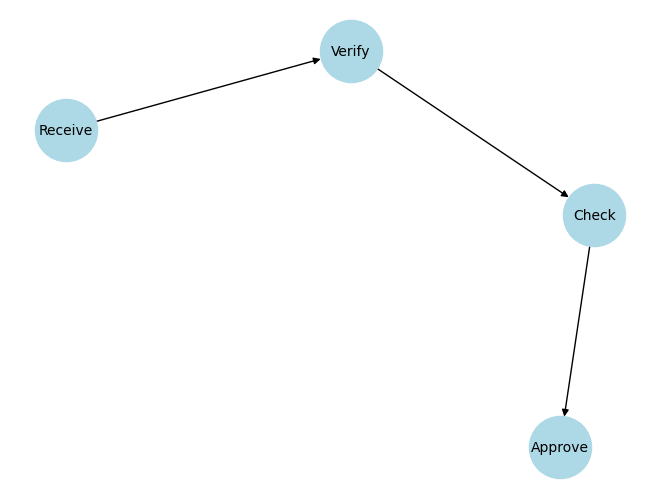

In [14]:
kyc = [
    ("Receive","Verify"),
    ("Verify","Check"),
    ("Check","Approve"),
]

draw_subgraph(kyc)

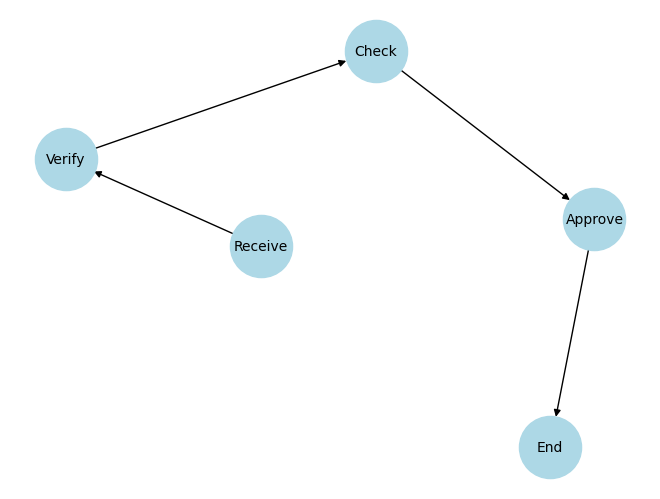

In [15]:
draw_subgraph([
    ("Receive","Verify"),
    ("Verify","Check"),
    ("Check","Approve"),
    ("Approve","End"),
])

## Process Mining cua Thay

In [16]:
# Cập nhật lên phiên bản mới nhất
!pip install --upgrade pm4py

# Hoặc cài đặt phiên bản cụ thể
!pip install pm4py==2.7.0

  Using cached pm4py-2.7.22-py3-none-any.whl.metadata (4.7 kB)
Using cached pm4py-2.7.22-py3-none-any.whl (2.5 MB)
  Attempting uninstall: pm4py
    Found existing installation: pm4py 2.7.0
    Uninstalling pm4py-2.7.0:
      Successfully uninstalled pm4py-2.7.0
  Using cached pm4py-2.7.0-py3-none-any.whl.metadata (3.1 kB)
Using cached pm4py-2.7.0-py3-none-any.whl (1.6 MB)
  Attempting uninstall: pm4py
    Found existing installation: pm4py 2.7.22
    Uninstalling pm4py-2.7.22:
      Successfully uninstalled pm4py-2.7.22


/usr/local/lib/python3.12/dist-packages/pm4py/objects/log/util/dataframe_utils.py:176: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], utc=True)
/usr/local/lib/python3.12/dist-packages/pm4py/objects/log/util/dataframe_utils.py:176: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], utc=True)


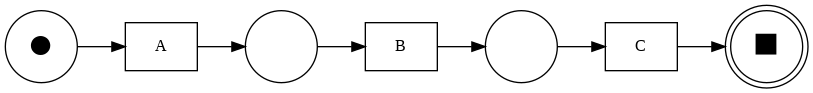

In [17]:
#Alpha Miner
import pm4py
from pm4py.objects.log.util import dataframe_utils
from pm4py.objects.conversion.log import converter as log_converter
from pm4py.algo.discovery.alpha import algorithm as alpha_miner
from pm4py.visualization.petri_net import visualizer as pn_visualizer
import pandas as pd

# 1. Tạo dữ liệu mẫu (Event Log)
# Trong thực tế, anh có thể đọc từ file .csv hoặc .xes
event_data = {
    'case:concept:name': ['1', '1', '1', '2', '2', '2', '3', '3', '3'],
    'concept:name': ['A', 'B', 'C', 'A', 'B', 'C', 'A', 'B', 'C'],
    'time:timestamp': pd.to_datetime([
        '2026-01-01 09:00', '2026-01-01 10:00', '2026-01-01 11:00',
        '2026-01-02 09:00', '2026-01-02 10:00', '2026-01-02 11:00',
        '2026-01-03 09:00', '2026-01-03 10:00', '2026-01-03 11:00'
    ])
}

df = pd.DataFrame(event_data)
df = dataframe_utils.convert_timestamp_columns_in_df(df)
df = df.sort_values('time:timestamp')

# Chuyển đổi DataFrame sang định dạng Log của pm4py
log = log_converter.apply(df)

# 2. Áp dụng thuật toán Alpha Miner
# Kết quả trả về gồm: Petri net (net), Trạng thái bắt đầu (im), Trạng thái kết thúc (fm)
net, initial_marking, final_marking = alpha_miner.apply(log)

# 3. Trực quan hóa mô hình Petri net
gviz = pn_visualizer.apply(net, initial_marking, final_marking)
pn_visualizer.view(gviz)

# 4. (Tùy chọn) Xuất file ảnh
# pn_visualizer.save(gviz, "alpha_miner_result.png")

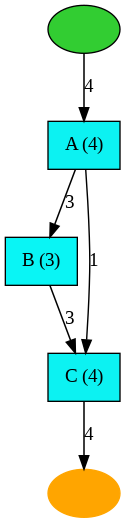

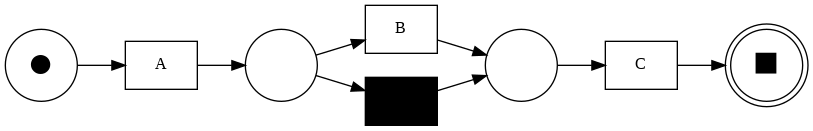

In [18]:
# Heuristic Mining

import pm4py
import pandas as pd

# 1. Tạo dữ liệu mẫu trực tiếp bằng DataFrame
event_data = {
    'case:concept:name': ['1', '1', '1', '2', '2', '2', '3', '3', '3', '4', '4'],
    'concept:name': ['A', 'B', 'C', 'A', 'B', 'C', 'A', 'B', 'C', 'A', 'C'],
    'time:timestamp': pd.to_datetime([
        '2026-01-01 09:00', '2026-01-01 10:00', '2026-01-01 11:00',
        '2026-01-02 09:00', '2026-01-02 10:00', '2026-01-02 11:00',
        '2026-01-03 09:00', '2026-01-03 10:00', '2026-01-03 11:00',
        '2026-01-04 09:00', '2026-01-04 10:00'
    ])
}
df = pd.DataFrame(event_data)

# 2. Khám phá Heuristics Net bằng hàm High-level
# Hàm này tự động xử lý việc chuyển đổi log và áp dụng thuật toán
heu_net = pm4py.discover_heuristics_net(df,
                                        dependency_threshold=0.5,
                                        case_id_key='case:concept:name',
                                        activity_key='concept:name',
                                        timestamp_key='time:timestamp')

# 3. Trực quan hóa
pm4py.view_heuristics_net(heu_net)

# 4. Nếu anh muốn chuyển sang Petri Net để phân tích toán học (Soundness)
net, im, fm = pm4py.discover_petri_net_heuristics(df,
                                                dependency_threshold=0.5,
                                                case_id_key='case:concept:name',
                                                activity_key='concept:name',
                                                timestamp_key='time:timestamp')
pm4py.view_petri_net(net, im, fm)

Đã chuyển đổi thành công Petri Net sang BPMN
BPMN Graph: ->( 'A', X( tau, 'B' ), X( tau, 'C' ) )


/usr/local/lib/python3.12/dist-packages/pm4py/utils.py:486: UserWarning: the EventLog class has been deprecated and will be removed in a future release.
  warnings.warn("the EventLog class has been deprecated and will be removed in a future release.")


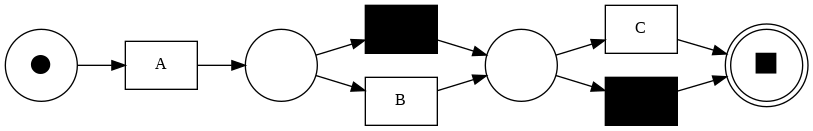

In [26]:
# Bien Petrinet thanh BPMN
import pm4py
from pm4py.objects.conversion.log import converter as log_converter
import pandas as pd

# Import các module cần thiết cho BPMN
from pm4py.objects.conversion.wf_net import converter as wf_converter
from pm4py.objects.bpmn.exporter import exporter as bpmn_exporter


# 1. Tạo dữ liệu mẫu và khám phá Petri Net bằng Inductive Miner
event_data = {
    'case:concept:name': ['1', '1', '1', '2', '2', '2', '3', '3', '4', '4'],
    'concept:name': ['A', 'B', 'C', 'A', 'B', 'C', 'A', 'C', 'A', 'B'],
    'time:timestamp': pd.to_datetime([
        '2026-01-01 09:00', '2026-01-01 10:00', '2026-01-01 11:00',
        '2026-01-02 09:00', '2026-01-02 10:00', '2026-01-02 11:00',
        '2026-01-03 09:00', '2026-01-03 10:00', '2026-01-04 09:00', '2026-01-04 10:00'
    ])
}
df = pd.DataFrame(event_data)

# Chuyển đổi DataFrame thành event log
event_log = log_converter.apply(df, variant=log_converter.Variants.TO_EVENT_LOG)

# Khám phá Petri Net
net, im, fm = pm4py.discover_petri_net_inductive(event_log)

# 2. Chuyển đổi Petri Net sang mô hình BPMN
# Sử dụng đúng cách import và hàm chuyển đổi
bpmn_graph = wf_converter.apply(net, im, fm)

# 3. Trực quan hóa kết quả BPMN
print("Đã chuyển đổi thành công Petri Net sang BPMN")
print(f"BPMN Graph: {bpmn_graph}")

# Hiển thị thông tin về BPMN graph
if hasattr(bpmn_graph, 'get_nodes'):
    print(f"Số lượng node trong BPMN: {len(bpmn_graph.get_nodes())}")

# 4. Xuất file BPMN (nếu muốn)
# bpmn_exporter.apply(bpmn_graph, "process_model.bpmn")
# print("Đã xuất file process_model.bpmn")

# 5. Hiển thị Petri Net để so sánh
pm4py.view_petri_net(net, im, fm)

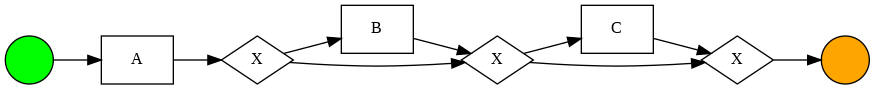

In [27]:
## Bien Petrinet thanh BPMN
import pm4py
import pandas as pd

# 1. Tạo dữ liệu mẫu
event_data = {
    'case:concept:name': ['1', '1', '1', '2', '2', '2', '3', '3', '4', '4'],
    'concept:name': ['A', 'B', 'C', 'A', 'B', 'C', 'A', 'C', 'A', 'B'],
    'time:timestamp': pd.to_datetime([
        '2026-01-01 09:00', '2026-01-01 10:00', '2026-01-01 11:00',
        '2026-01-02 09:00', '2026-01-02 10:00', '2026-01-02 11:00',
        '2026-01-03 09:00', '2026-01-03 10:00', '2026-01-04 09:00', '2026-01-04 10:00'
    ])
}
df = pd.DataFrame(event_data)

# 2. Khám phá Petri Net bằng Inductive Miner (High-level)
net, im, fm = pm4py.discover_petri_net_inductive(df)

# 3. CHUYỂN ĐỔI: Sử dụng hàm trực tiếp từ pm4py
# Đây là cách thay thế cho module pn_to_bpmn_converter cũ
bpmn_graph = pm4py.convert_to_bpmn(net, im, fm)

# 4. Trực quan hóa
pm4py.view_bpmn(bpmn_graph)

# 5. Lưu ra file để đồng nghiệp mở bằng Camunda/Bizagi (nếu cần)
# pm4py.write_bpmn(bpmn_graph, "model_ket_qua.bpmn")

Đã lưu event log vào: /content/sample_data/event_log.csv
Số lượng cases: 5
Số lượng events: 20

Preview của event log:
  case:concept:name             concept:name      time:timestamp
0                 1         Inspect Building 2026-03-17 08:00:00
1                 1      Complete Inspection 2026-03-17 09:00:00
2                 1  Send Email Notification 2026-03-17 09:10:00
3                 1          Prepare Invoice 2026-03-17 10:00:00
4                 1         Generate Invoice 2026-03-17 10:30:00
5                 2         Inspect Building 2026-03-17 08:15:00
6                 2     Inspection Cancelled 2026-03-17 08:45:00
7                 3         Inspect Building 2026-03-17 08:30:00
8                 3      Complete Inspection 2026-03-17 09:30:00
9                 3  Send Email Notification 2026-03-17 09:40:00


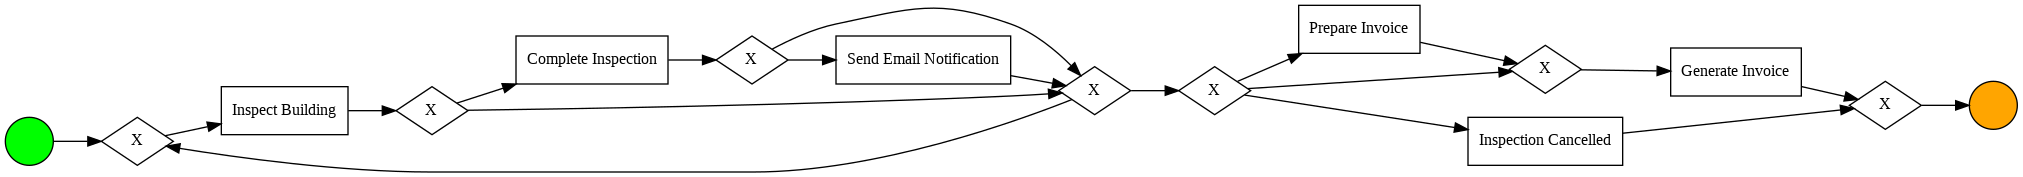

In [33]:
## Ve so do BPMN
import pm4py
import pandas as pd

# 1. Khởi tạo dữ liệu (Dựa trên kịch bản Building Inspection đã tạo ở trên)
event_data = {
    'case:concept:name': [
        '1', '1', '1', '1', '1',
        '2', '2',
        '3', '3', '3', '3', '3', '3',
        '4', '4', '4', '4', '4',
        '5', '5'
    ],
    'concept:name': [
        'Inspect Building', 'Complete Inspection', 'Send Email Notification', 'Prepare Invoice', 'Generate Invoice',
        'Inspect Building', 'Inspection Cancelled',
        'Inspect Building', 'Complete Inspection', 'Send Email Notification', 'Inspect Building', 'Complete Inspection', 'Generate Invoice',
        'Inspect Building', 'Complete Inspection', 'Send Email Notification', 'Prepare Invoice', 'Generate Invoice',
        'Inspect Building', 'Inspection Cancelled'
    ],
    'time:timestamp': pd.to_datetime([
        '2026-03-17 08:00', '2026-03-17 09:00', '2026-03-17 09:10', '2026-03-17 10:00', '2026-03-17 10:30',
        '2026-03-17 08:15', '2026-03-17 08:45',
        '2026-03-17 08:30', '2026-03-17 09:30', '2026-03-17 09:40', '2026-03-17 11:00', '2026-03-17 12:00', '2026-03-17 12:30',
        '2026-03-18 08:00', '2026-03-18 09:00', '2026-03-18 09:15', '2026-03-18 10:00', '2026-03-18 10:45',
        '2026-03-18 08:30', '2026-03-18 09:00'
    ])
}

df = pd.DataFrame(event_data)
# LƯU EVENT LOG VÀO FILE CSV
# Đường dẫn lưu file
csv_path = '/content/sample_data/event_log.csv'

# Lưu DataFrame thành file CSV
df.to_csv(csv_path, index=False, encoding='utf-8')
print(f"Đã lưu event log vào: {csv_path}")
print(f"Số lượng cases: {df['case:concept:name'].nunique()}")
print(f"Số lượng events: {len(df)}")
print("\nPreview của event log:")
print(df.head(10))
# 2. Khám phá mô hình bằng Inductive Miner
# Thuật toán này rất mạnh trong việc phát hiện loop và branch từ log
net, im, fm = pm4py.discover_petri_net_inductive(df,
                                                 case_id_key='case:concept:name',
                                                 activity_key='concept:name',
                                                 timestamp_key='time:timestamp')

# 3. Chuyển đổi Petri Net vừa khám phá sang định dạng BPMN
bpmn_graph = pm4py.convert_to_bpmn(net, im, fm)

# 4. Trực quan hóa sơ đồ BPMN
pm4py.view_bpmn(bpmn_graph)

# 5. (Tùy chọn) Xuất file để kiểm tra cấu trúc XML
# pm4py.write_bpmn(bpmn_graph, "building_inspection_model.bpmn")

In [29]:
!pip install graphviz

In [34]:
### Ve BPMN Diagram
from graphviz import Digraph

# Create BPMN diagram
bpmn = Digraph('BPMN', format='png')
bpmn.attr(rankdir='LR')  # Left to Right layout

# Start Event
bpmn.node('Start', shape='circle', label='Start')

# Tasks
bpmn.node('T1', shape='box')
bpmn.node('T2', shape='box')
bpmn.node('T3', shape='box')
bpmn.node('T4', shape='box')

# Gateways (XOR)
bpmn.node('G1', shape='diamond', label='check')
bpmn.node('G2', shape='diamond')

# End Event
bpmn.node('End', shape='doublecircle', label='End')

# Edges
bpmn.edge('Start', 'T1')
bpmn.edge('T1', 'G1')

# XOR split
bpmn.edge('G1', 'T2', label='Y')
bpmn.edge('G1', 'T3', label='N')

# Merge gateway
bpmn.edge('T2', 'G2')
bpmn.edge('T3', 'G2')

# Continue
bpmn.edge('G2', 'T4')
bpmn.edge('T4', 'End')

# Render diagram
bpmn.render('bpmn_diagram', view=True)

'bpmn_diagram.png'

In [35]:
### Ve PetriNet
from graphviz import Digraph

pn = Digraph("PetriNet", format="png")
pn.attr(rankdir="LR")

# ----- Places (circles) -----
places = ["P0","P1","P2","P3","P4","P5","P6"]
for p in places:
    pn.node(p, shape="circle")

# ----- Transitions (rectangles) -----
transitions = {
    "T1":"T1",
    "T2":"T2",
    "T3":"T3",
    "T4":"T4",
    "X1":"XOR",
    "X2":"XOR"
}

for t,label in transitions.items():
    pn.node(t, label=label, shape="box")

# ----- Flow relation -----

# Start
pn.edge("P0","T1")
pn.edge("T1","P1")

# XOR split
pn.edge("P1","X1")
pn.edge("X1","P2")
pn.edge("X1","P3")

# Branch tasks
pn.edge("P2","T2")
pn.edge("T2","P4")

pn.edge("P3","T3")
pn.edge("T3","P5")

# XOR merge
pn.edge("P4","X2")
pn.edge("P5","X2")

pn.edge("X2","P6")

# Final task
pn.edge("P6","T4")
pn.edge("T4","P0_end")

# End place
pn.node("P0_end", shape="doublecircle", label="End")

# Render
pn.render("petri_net_bpmn", view=True)

'petri_net_bpmn.png'

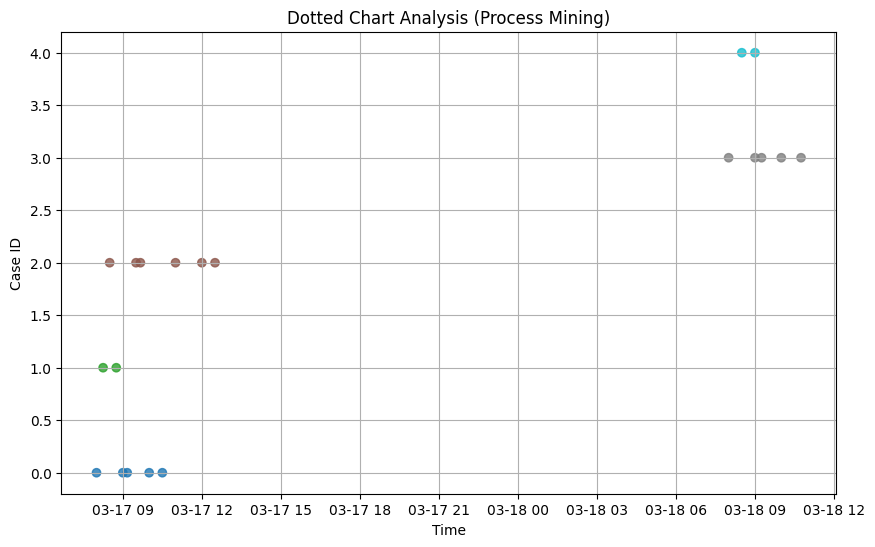

In [40]:
## Chương trình Python Dotted Chart Analysis
import pandas as pd
import matplotlib.pyplot as plt

# Load event log
log = pd.read_csv("/content/sample_data/event_log.csv")

# Convert timestamp
log["time:timestamp"] = pd.to_datetime(log["time:timestamp"])

# Sort events
log = log.sort_values("time:timestamp")

# Map case_id to numeric values
log["case_num"] = log["case:concept:name"].astype("category").cat.codes

# Plot dotted chart
plt.figure(figsize=(10,6))

plt.scatter(
    log["time:timestamp"],
    log["case_num"],
    c=log["case_num"],
    cmap="tab10",
    alpha=0.8
)

plt.xlabel("Time")
plt.ylabel("Case ID")
plt.title("Dotted Chart Analysis (Process Mining)")

plt.grid(True)
plt.show()

In [41]:
### Python Code: Decision Tree Mining
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Load event log
log = pd.read_csv("/content/sample_data/event_log_1.csv")

# Encode categorical data
le_customer = LabelEncoder()
le_decision = LabelEncoder()

log["customer_type"] = le_customer.fit_transform(log["customer_type"])
log["decision"] = le_decision.fit_transform(log["decision"])

# Features and target
X = log[["amount", "customer_type"]]
y = log["decision"]

# Train decision tree
model = DecisionTreeClassifier(max_depth=3)
model.fit(X, y)

# Plot decision tree
plt.figure(figsize=(10,6))
plot_tree(
    model,
    feature_names=["amount", "customer_type"],
    class_names=le_decision.classes_,
    filled=True
)

plt.title("Decision Tree Mining (Process Mining)")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/sample_data/event_log_1.csv'

In [ ]:
## Frequent Subgraph Mining
import networkx as nx
from itertools import combinations

# -----------------------------
# Tao tap do thi vi du
# -----------------------------
def create_graph_dataset():
    graphs = []

    # Graph 1
    g1 = nx.Graph()
    g1.add_edge("A", "B", label="x")
    g1.add_edge("B", "C", label="y")
    graphs.append(g1)

    # Graph 2
    g2 = nx.Graph()
    g2.add_edge("A", "B", label="x")
    g2.add_edge("B", "D", label="z")
    graphs.append(g2)

    # Graph 3
    g3 = nx.Graph()
    g3.add_edge("A", "B", label="x")
    g3.add_edge("B", "C", label="y")
    graphs.append(g3)

    return graphs


# -----------------------------
# Kiem tra subgraph isomorphism
# -----------------------------
def is_subgraph(g_small, g_large):
    matcher = nx.algorithms.isomorphism.GraphMatcher(g_large, g_small)
    return matcher.subgraph_is_isomorphic()


# -----------------------------
# Tao tat ca subgraph tu graph
# -----------------------------
def generate_subgraphs(graph):
    nodes = list(graph.nodes())
    subgraphs = []

    for r in range(2, len(nodes) + 1):
        for subset in combinations(nodes, r):
            sg = graph.subgraph(subset).copy()
            if sg.number_of_edges() > 0:
                subgraphs.append(sg)

    return subgraphs


# -----------------------------
# Frequent Subgraph Mining
# -----------------------------
def frequent_subgraph_mining(graphs, min_support=2):

    candidate_subgraphs = []

    for g in graphs:
        candidate_subgraphs.extend(generate_subgraphs(g))

    unique_subgraphs = []

    for sg in candidate_subgraphs:
        found = False

        for usg in unique_subgraphs:
            matcher = nx.algorithms.isomorphism.GraphMatcher(usg, sg)
            if matcher.is_isomorphic():
                found = True
                break

        if not found:
            unique_subgraphs.append(sg)

    results = []

    for sg in unique_subgraphs:
        support = 0

        for g in graphs:
            if is_subgraph(sg, g):
                support += 1

        if support >= min_support:
            results.append((sg, support))

    return results


# -----------------------------
# In ket qua
# -----------------------------
def print_results(results):

    for i, (sg, support) in enumerate(results):

        print("\nFrequent Subgraph", i + 1)
        print("Support:", support)

        print("Nodes:")
        for n in sg.nodes():
            print(n)

        print("Edges:")
        for u, v in sg.edges():
            print(u, "-", v)


# -----------------------------
# Main
# -----------------------------
def main():

    graphs = create_graph_dataset()

    min_support = 2

    results = frequent_subgraph_mining(graphs, min_support)

    print_results(results)


if __name__ == "__main__":
    main()

## Event log

In [1]:
!pip install pm4py graphviz

!pip install --upgrade pm4py

# Hoặc cài đặt phiên bản cụ thể
!pip install pm4py==2.7.0

  Using cached pm4py-2.7.0-py3-none-any.whl.metadata (3.1 kB)
Using cached pm4py-2.7.0-py3-none-any.whl (1.6 MB)
  Attempting uninstall: pm4py
    Found existing installation: pm4py 2.7.22
    Uninstalling pm4py-2.7.22:
      Successfully uninstalled pm4py-2.7.22


In [2]:
import pandas as pd

data = [
[1,"Inspect Building","2024-01-01 08:00:00"],
[1,"Complete Inspection","2024-01-01 08:10:00"],
[1,"Send Email Notification","2024-01-01 08:15:00"],
[1,"Prepare Invoice","2024-01-01 08:20:00"],
[1,"Generate Invoice","2024-01-01 08:25:00"],

[2,"Inspect Building","2024-01-02 09:00:00"],
[2,"Inspect Building","2024-01-02 09:10:00"],
[2,"Complete Inspection","2024-01-02 09:20:00"],
[2,"Send Email Notification","2024-01-02 09:25:00"],
[2,"Prepare Invoice","2024-01-02 09:30:00"],
[2,"Generate Invoice","2024-01-02 09:35:00"],

[3,"Inspect Building","2024-01-03 10:00:00"],

[4,"Inspect Building","2024-01-04 11:00:00"],
[4,"Complete Inspection","2024-01-04 11:10:00"],
[4,"Send Email Notification","2024-01-04 11:15:00"],
]

df = pd.DataFrame(
    data,
    columns=[
        "case:concept:name",
        "concept:name",
        "time:timestamp"
    ]
)

df.to_csv("event_log.csv", index=False)

In [3]:
import pm4py
import pandas as pd

df = pd.read_csv("event_log.csv")

df = pm4py.format_dataframe(
    df,
    case_id="case:concept:name",
    activity_key="concept:name",
    timestamp_key="time:timestamp"
)

log = pm4py.convert_to_event_log(df)

/tmp/ipykernel_23856/1286183848.py:6: DeprecatedWarning: format_dataframe is deprecated as of 2.3.0 and will be removed in 3.0.0. the format_dataframe function does not need application anymore.
  df = pm4py.format_dataframe(
/usr/local/lib/python3.12/dist-packages/pm4py/objects/log/util/dataframe_utils.py:176: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], utc=True)
/usr/local/lib/python3.12/dist-packages/pm4py/utils.py:486: UserWarning: the EventLog class has been deprecated and will be removed in a future release.
  warnings.warn("the EventLog class has been deprecated and will be removed in a future release.")


In [4]:
from pm4py.algo.discovery.alpha import algorithm as alpha_miner
from pm4py.visualization.petri_net import visualizer as pn_vis
from pm4py.objects.conversion.petri_net import converter as pn_converter
from pm4py.visualization.bpmn import visualizer as bpmn_vis
import pm4py

# alpha miner
net, im, fm = alpha_miner.apply(log)

# show petri
gviz = pn_vis.apply(net, im, fm)
pn_vis.view(gviz)

# petri -> tree
tree = pn_converter.apply(net, im, fm)

# tree -> bpmn
bpmn_graph = pm4py.convert_to_bpmn(tree)

# show bpmn
gviz = bpmn_vis.apply(bpmn_graph)
bpmn_vis.view(gviz)

ModuleNotFoundError: No module named 'pm4py.objects.conversion.petri_net'

AttributeError: module 'pm4py.algo.discovery.inductive.algorithm' has no attribute 'apply_tree'